In [8]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve
)

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Explainability
import shap
from lime.lime_tabular import LimeTabularExplainer

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully.")

All libraries imported successfully.


In [9]:
!pip install lime -q

In [10]:
df = pd.read_csv("insurance.csv")

print("Shape:", df.shape)
display(df.head())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicates: 1


In [11]:
print(df["charges"].describe())
print("\nMedian:", df["charges"].median())
print("\nQuartiles:")
print(df["charges"].quantile([0.25, 0.50, 0.75]))

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

Median: 9382.033

Quartiles:
0.25     4740.287150
0.50     9382.033000
0.75    16639.912515
Name: charges, dtype: float64


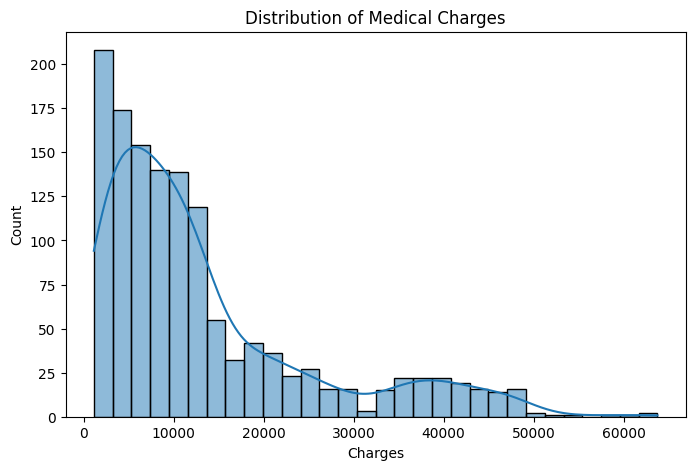

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["charges"], kde=True)
plt.title("Distribution of Medical Charges")
plt.xlabel("Charges")
plt.show()

In [13]:
for col in ["sex", "smoker", "region"]:
    print(f"\n{col}:")
    print(df[col].value_counts())


sex:
sex
male      676
female    662
Name: count, dtype: int64

smoker:
smoker
no     1064
yes     274
Name: count, dtype: int64

region:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


In [14]:
df[["age", "bmi", "children"]].describe()

,age,bmi,children
count,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918
std,14.049960,6.098187,1.205493
min,18.000000,15.960000,0.000000
25%,27.000000,26.296250,0.000000
50%,39.000000,30.400000,1.000000
75%,51.000000,34.693750,2.000000
max,64.000000,53.130000,5.000000


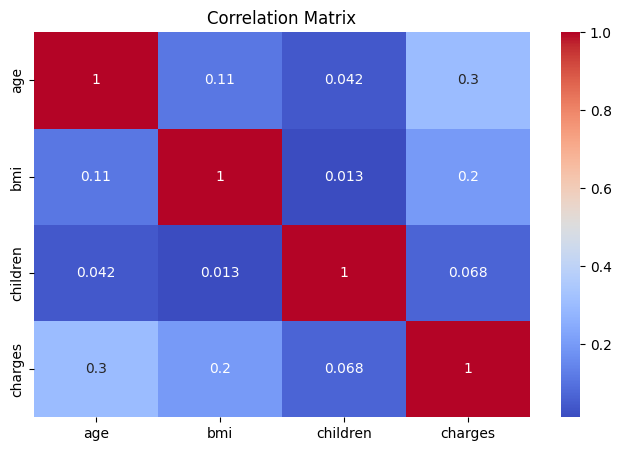

In [15]:
plt.figure(figsize=(8,5))
sns.heatmap(df.select_dtypes("number").corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

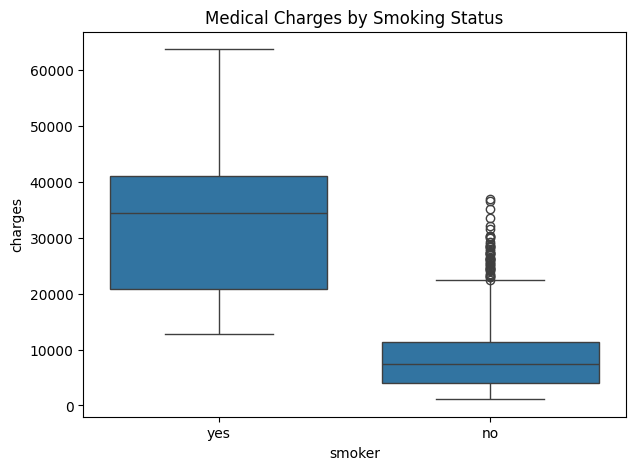

In [16]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="smoker", y="charges")
plt.title("Medical Charges by Smoking Status")
plt.show()

In [17]:
threshold = df["charges"].median()
df["High_Cost"] = (df["charges"] >= threshold).astype(int)

print("Threshold:", threshold)
print(df["High_Cost"].value_counts())

Threshold: 9382.033
High_Cost
1    669
0    669
Name: count, dtype: int64


In [18]:
print(df["High_Cost"].value_counts(normalize=True) * 100)

High_Cost
1    50.0
0    50.0
Name: proportion, dtype: float64


In [19]:
X = df.drop(columns=["charges", "High_Cost"])
y = df["High_Cost"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(1070, 6) (268, 6)


In [21]:
categorical_features = ["sex", "smoker", "region"]
numerical_features = ["age", "bmi", "children"]

In [22]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

In [23]:
logistic = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [24]:
random_forest = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42))
])

In [25]:
decision_tree = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

In [26]:
xgboost = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        random_state=42,
        eval_metric="logloss"
    ))
])

In [27]:
estimators = [
    ("lr", LogisticRegression(max_iter=1000)),
    ("rf", RandomForestClassifier(n_estimators=100, random_state=42)),
    ("dt", DecisionTreeClassifier(random_state=42))
]

In [28]:
stacking = Pipeline([
    ("preprocessor", preprocessor),
    ("model", StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(max_iter=1000)
    ))
])

In [29]:
models = {
    "Logistic Regression": logistic,
    "Random Forest": random_forest,
    "Decision Tree": decision_tree,
    "XGBoost": xgboost,
    "Stacked Ensemble": stacking
}

In [30]:
import time

results = []

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "Training Time (s)": train_time
    })

results_df = pd.DataFrame(results)
results_df

,Model,Precision,Recall,F1,ROC-AUC,Training Time (s)
0,Logistic Regression,0.884892,0.917910,0.901099,0.942526,0.076606
1,Random Forest,0.975806,0.902985,0.937984,0.949042,1.430671
2,Decision Tree,0.880597,0.880597,0.880597,0.880597,0.059055
3,XGBoost,0.983740,0.902985,0.941634,0.950490,1.343059
4,Stacked Ensemble,0.960630,0.910448,0.934866,0.946480,1.693032


In [31]:
results_df.round(4)

,Model,Precision,Recall,F1,ROC-AUC,Training Time (s)
0,Logistic Regression,0.8849,0.9179,0.9011,0.9425,0.0766
1,Random Forest,0.9758,0.9030,0.9380,0.9490,1.4307
2,Decision Tree,0.8806,0.8806,0.8806,0.8806,0.0591
3,XGBoost,0.9837,0.9030,0.9416,0.9505,1.3431
4,Stacked Ensemble,0.9606,0.9104,0.9349,0.9465,1.6930


In [32]:
results_df.sort_values("F1", ascending=False)

,Model,Precision,Recall,F1,ROC-AUC,Training Time (s)
3,XGBoost,0.983740,0.902985,0.941634,0.950490,1.343059
1,Random Forest,0.975806,0.902985,0.937984,0.949042,1.430671
4,Stacked Ensemble,0.960630,0.910448,0.934866,0.946480,1.693032
0,Logistic Regression,0.884892,0.917910,0.901099,0.942526,0.076606
2,Decision Tree,0.880597,0.880597,0.880597,0.880597,0.059055


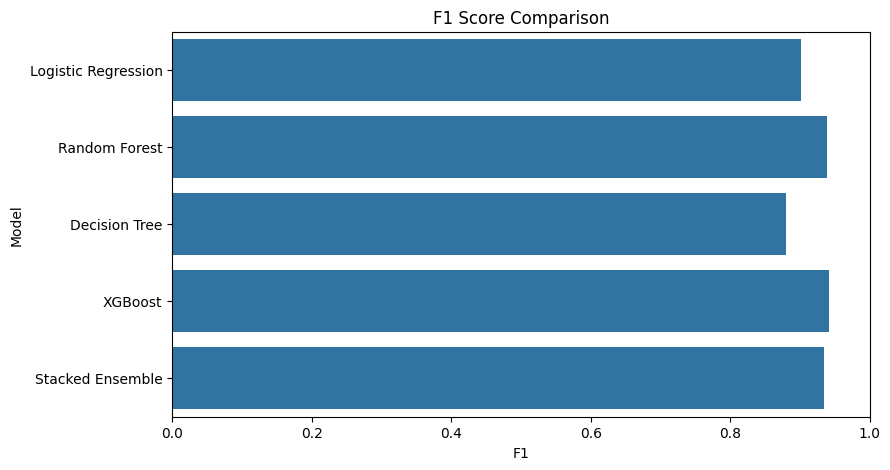

In [33]:
plt.figure(figsize=(9,5))
sns.barplot(data=results_df, x="F1", y="Model")
plt.title("F1 Score Comparison")
plt.xlim(0, 1)
plt.show()

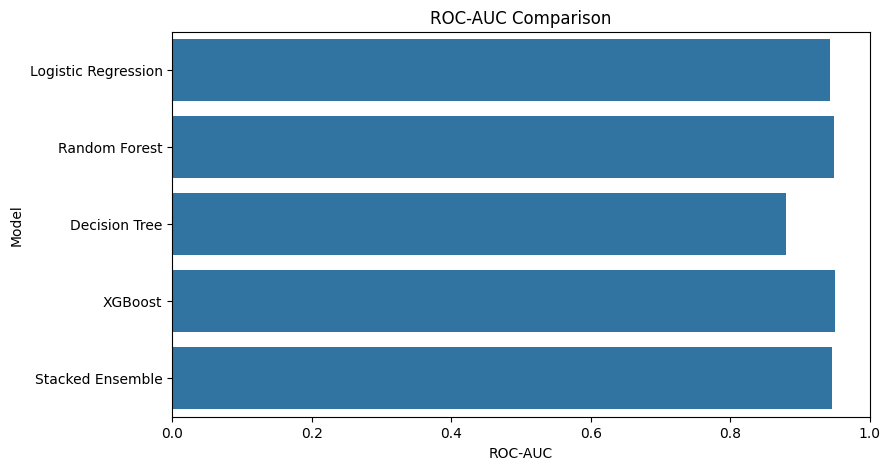

In [34]:
plt.figure(figsize=(9,5))
sns.barplot(data=results_df, x="ROC-AUC", y="Model")
plt.title("ROC-AUC Comparison")
plt.xlim(0, 1)
plt.show()

In [35]:
best_model_name = results_df.loc[results_df["F1"].idxmax(), "Model"]
best_model = models[best_model_name]

print("Best Model:", best_model_name)

Best Model: XGBoost


In [36]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

In [37]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

In [38]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Low Cost", "High Cost"]
))

              precision    recall  f1-score   support

    Low Cost       0.91      0.99      0.95       134
   High Cost       0.98      0.90      0.94       134

    accuracy                           0.94       268
   macro avg       0.95      0.94      0.94       268
weighted avg       0.95      0.94      0.94       268



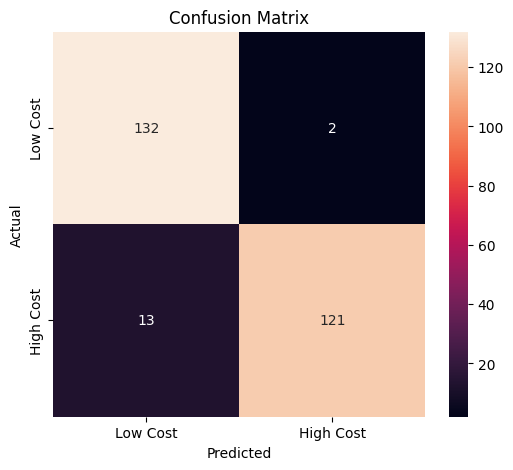

In [39]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Low Cost", "High Cost"],
    yticklabels=["Low Cost", "High Cost"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

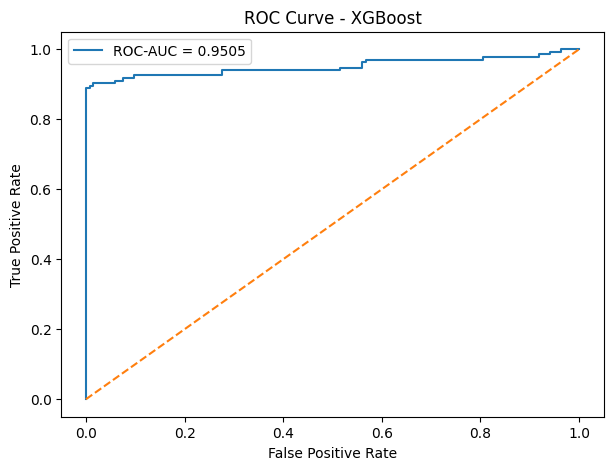

In [40]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, y_prob):.4f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {best_model_name}")
plt.legend()
plt.show()

In [41]:
import joblib

joblib.dump(best_model, "final_model.pkl")
print("Final model saved as final_model.pkl")

Final model saved as final_model.pkl


In [42]:
X_test_transformed = best_model.named_steps["preprocessor"].transform(X_test)

In [43]:
model_only = best_model.named_steps["model"]

In [44]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
print(feature_names)

['num__age' 'num__bmi' 'num__children' 'cat__sex_female' 'cat__sex_male'
 'cat__smoker_no' 'cat__smoker_yes' 'cat__region_northeast'
 'cat__region_northwest' 'cat__region_southeast' 'cat__region_southwest']


In [45]:
explainer = shap.TreeExplainer(model_only)

In [46]:
shap_values = explainer.shap_values(X_test_transformed)

In [47]:
if isinstance(shap_values, list):
    shap_values_plot = shap_values[1]
else:
    shap_values_plot = shap_values

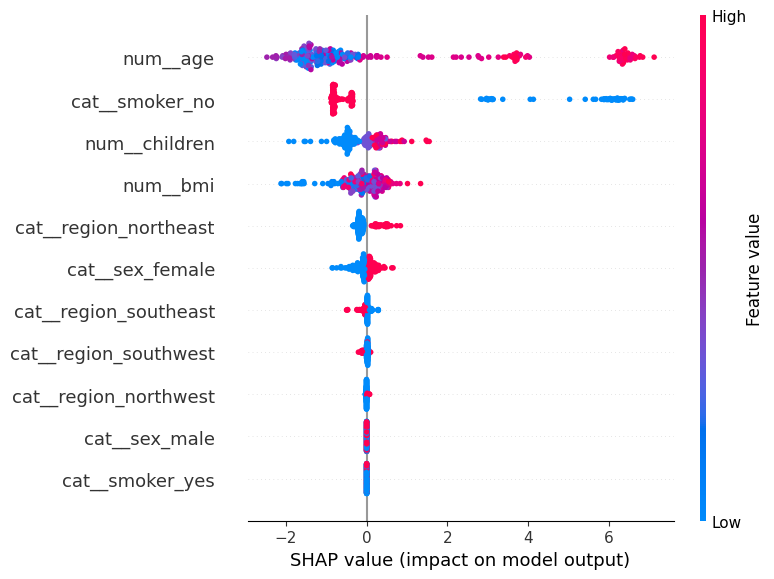

In [48]:
shap.summary_plot(
    shap_values_plot,
    X_test_transformed,
    feature_names=feature_names
)

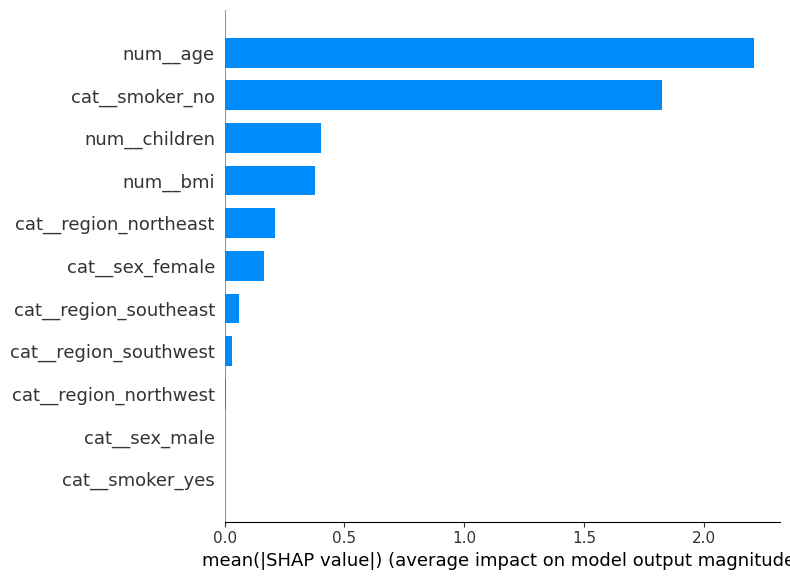

In [49]:
shap.summary_plot(
    shap_values_plot,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

In [50]:
sample_index = 0
sample = X_test_transformed[sample_index:sample_index+1]

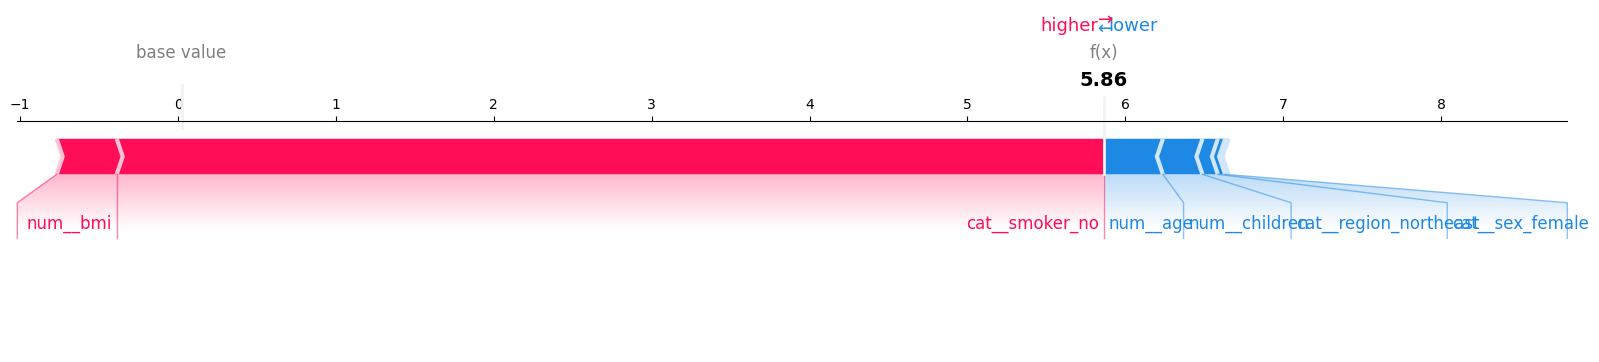

In [51]:
shap.force_plot(
    explainer.expected_value,
    shap_values_plot[sample_index],
    feature_names=feature_names,
    matplotlib=True
)
plt.show()

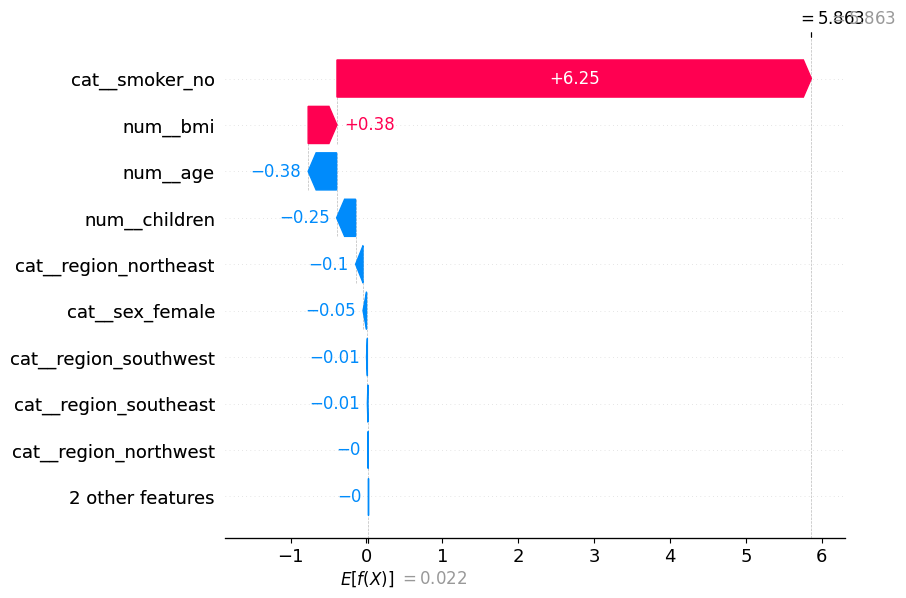

In [52]:
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values_plot[sample_index],
    feature_names=feature_names,
    max_display=10
)

In [53]:
sample_indices = [0, 1, 2]

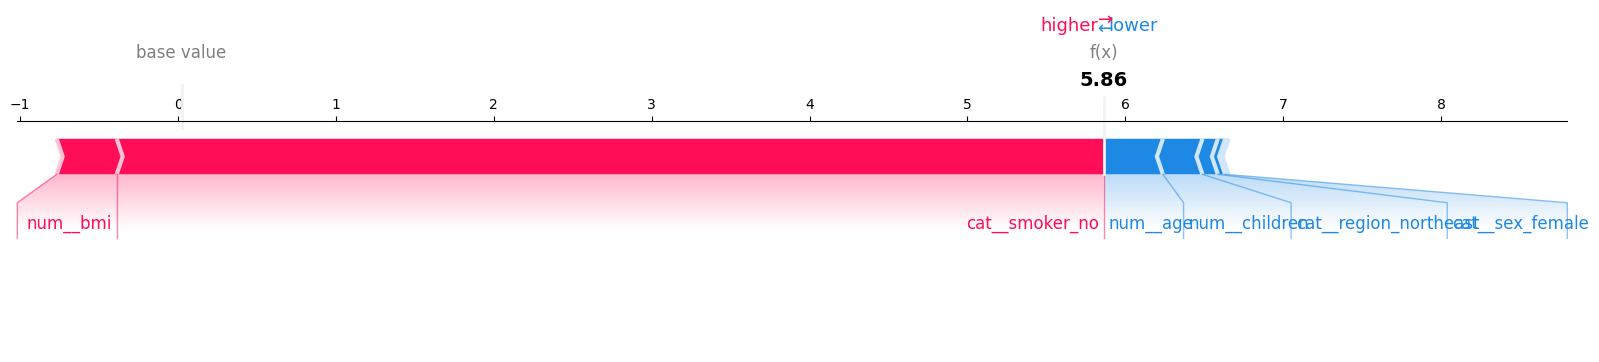

In [54]:
shap.force_plot(
    explainer.expected_value,
    shap_values_plot[0],
    feature_names=feature_names,
    matplotlib=True
)
plt.show()

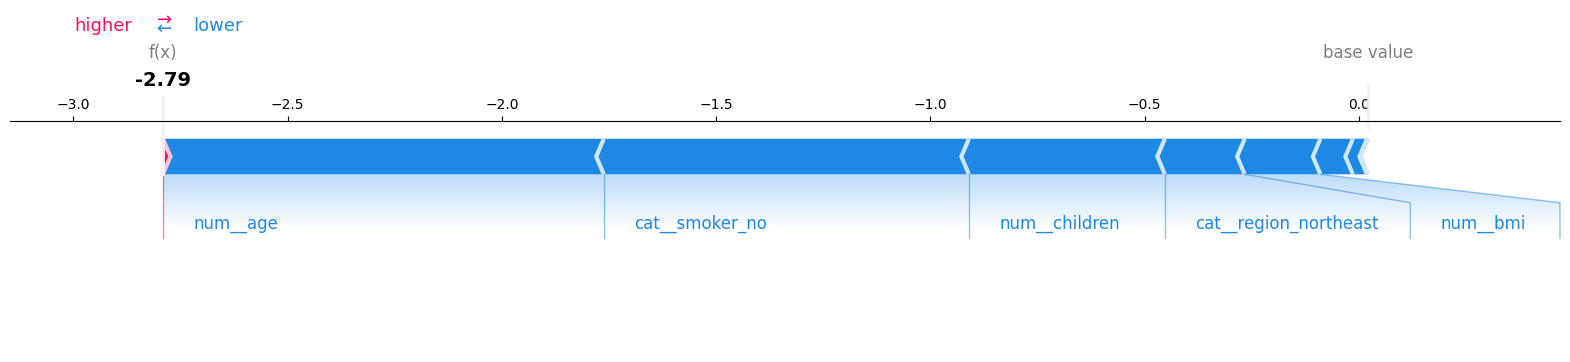

In [55]:
shap.force_plot(
    explainer.expected_value,
    shap_values_plot[1],
    feature_names=feature_names,
    matplotlib=True
)
plt.show()

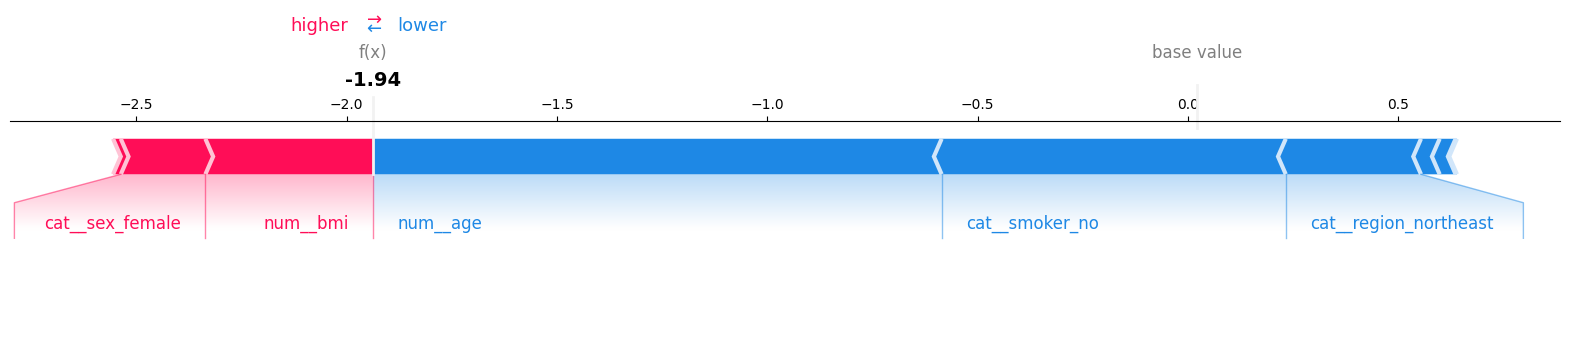

In [56]:
shap.force_plot(
    explainer.expected_value,
    shap_values_plot[2],
    feature_names=feature_names,
    matplotlib=True
)
plt.show()

In [57]:
X_train_transformed = best_model.named_steps["preprocessor"].transform(X_train)
X_train_transformed = X_train_transformed.toarray() if hasattr(X_train_transformed, "toarray") else X_train_transformed

In [58]:
lime_explainer = LimeTabularExplainer(
    X_train_transformed,
    feature_names=feature_names,
    class_names=["Low Cost", "High Cost"],
    mode="classification",
    random_state=42
)

In [61]:
def predict_proba_lime(x):
    return model_only.predict_proba(x)

In [62]:
lime_exp = lime_explainer.explain_instance(
    X_test_transformed.toarray()[0] if hasattr(X_test_transformed, "toarray") else X_test_transformed[0],
    predict_proba_lime,
    num_features=10
)

In [63]:
lime_exp.show_in_notebook(show_table=True)

In [64]:
lime_exp2 = lime_explainer.explain_instance(
    X_test_transformed.toarray()[1] if hasattr(X_test_transformed, "toarray") else X_test_transformed[1],
    predict_proba_lime,
    num_features=10
)
lime_exp2.show_in_notebook(show_table=True)

In [65]:
lime_exp3 = lime_explainer.explain_instance(
    X_test_transformed.toarray()[2] if hasattr(X_test_transformed, "toarray") else X_test_transformed[2],
    predict_proba_lime,
    num_features=10
)
lime_exp3.show_in_notebook(show_table=True)

In [66]:
for i in [0, 1, 2]:
    print(f"Case {i+1}: Actual={y_test.iloc[i]}, Predicted={y_pred[i]}")

Case 1: Actual=1, Predicted=1
Case 2: Actual=0, Predicted=0
Case 3: Actual=0, Predicted=0


In [67]:
prediction_summary = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability_High_Cost": y_prob
})

prediction_summary.head(10)

,Actual,Predicted,Probability_High_Cost
0,1,1,0.997166
1,0,0,0.057810
2,0,0,0.125897
3,1,1,0.996926
4,0,0,0.075590
5,0,0,0.028142
6,1,1,0.994701
7,1,0,0.257287
8,0,0,0.019422
9,1,1,0.996584


In [68]:
false_positives = prediction_summary[
    (prediction_summary["Actual"] == 0) &
    (prediction_summary["Predicted"] == 1)
]

print("False Positives:", len(false_positives))

False Positives: 2


In [69]:
false_negatives = prediction_summary[
    (prediction_summary["Actual"] == 1) &
    (prediction_summary["Predicted"] == 0)
]

print("False Negatives:", len(false_negatives))

False Negatives: 13


In [70]:
final_metrics = results_df[
    results_df["Model"] == best_model_name
]

final_metrics.round(4)

,Model,Precision,Recall,F1,ROC-AUC,Training Time (s)
3,XGBoost,0.9837,0.903,0.9416,0.9505,1.3431


In [71]:
joblib.dump(best_model, "final_model.pkl")

['final_model.pkl']

In [72]:
df.to_csv("insurance_classification.csv", index=False)

In [73]:
import os

print("final_model.pkl:", os.path.exists("final_model.pkl"))
print("insurance_classification.csv:", os.path.exists("insurance_classification.csv"))

final_model.pkl: True
insurance_classification.csv: True


In [74]:
sample_input = X_test.iloc[[0]]
print("Prediction:", best_model.predict(sample_input)[0])

Prediction: 1


In [75]:
print("Probability:", best_model.predict_proba(sample_input)[0])

Probability: [0.00283438 0.9971656 ]


In [76]:
def predict_high_cost(data):
    prediction = best_model.predict(data)[0]
    probability = best_model.predict_proba(data)[0, 1]
    return prediction, probability

predict_high_cost(sample_input)

(np.int64(1), np.float32(0.9971656))

In [77]:
test_samples = X_test.iloc[:5]
predictions = best_model.predict(test_samples)
probabilities = best_model.predict_proba(test_samples)[:, 1]

pd.DataFrame({
    "Actual": y_test.iloc[:5].values,
    "Predicted": predictions,
    "High_Cost_Probability": probabilities
})

,Actual,Predicted,High_Cost_Probability
0,1,1,0.997166
1,0,0,0.057810
2,0,0,0.125897
3,1,1,0.996926
4,0,0,0.075590


In [78]:
cm = confusion_matrix(y_test, y_pred)

print("False Positives:", cm[0, 1])
print("False Negatives:", cm[1, 0])

False Positives: 2
False Negatives: 13


In [79]:
results_df.sort_values("F1", ascending=False).round(4)

,Model,Precision,Recall,F1,ROC-AUC,Training Time (s)
3,XGBoost,0.9837,0.9030,0.9416,0.9505,1.3431
1,Random Forest,0.9758,0.9030,0.9380,0.9490,1.4307
4,Stacked Ensemble,0.9606,0.9104,0.9349,0.9465,1.6930
0,Logistic Regression,0.8849,0.9179,0.9011,0.9425,0.0766
2,Decision Tree,0.8806,0.8806,0.8806,0.8806,0.0591


In [82]:
import joblib

joblib.dump(best_model, "final_model.pkl")
print("Model saved successfully.")

Model saved successfully.


In [83]:
df.to_csv("insurance_classification.csv", index=False)
print("Dataset saved successfully.")

Dataset saved successfully.


In [84]:
import os

for file in ["final_model.pkl", "insurance_classification.csv"]:
    print(file, "->", os.path.getsize(file), "bytes")

final_model.pkl -> 256404 bytes
insurance_classification.csv -> 57037 bytes
